In [26]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere
import torch
import random
import math

In [27]:
scene = Scene()

# material
diffuse = read_image("assets/wood_olive/wood_olive_wood_olive_diffuse.png")
specular = read_image("assets/wood_olive/wood_olive_wood_olive_specular.png")
roughness = read_image("assets/wood_olive/wood_olive_wood_olive_roughness.png")

scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 50
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)

def random_point_on_unit_sphere():
    u = random.random()
    v = random.random()
    theta = 2 * math.pi * u
    phi = math.acos(2 * v - 1)
    x = math.sin(phi) * math.cos(theta)
    y = math.sin(phi) * math.sin(theta)
    z = math.cos(phi)
    return (x, y, z)

scene.set(f'sensor0', PerspectiveCamera.from_lookat(fov, random_point_on_unit_sphere(), target, up))

In [28]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
I_t = torch.stack([renderer(scene, sensor_ids=[0]) for _ in range(8)]).mean(axis=0)

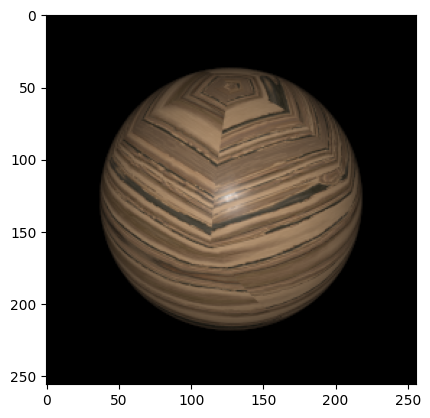

In [29]:
plt.imshow(I_t.cpu()[0]**0.454)

In [4]:
diffuse_GT = scene['mat']['d']
roughness_GT = scene['mat']['r']

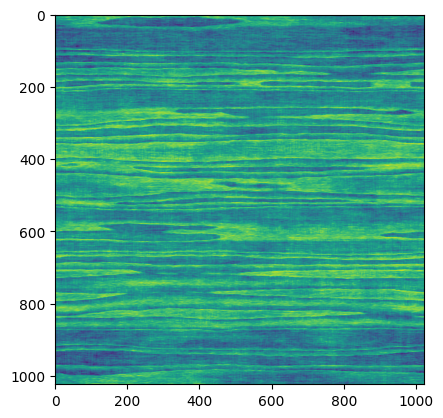

In [8]:
from matplotlib import pyplot as plt
plt.imshow(diffuse_GT.cpu()**0.454)
plt.imshow(roughness_GT.cpu()**0.454)

## Optimize

In [30]:
from ivt.model import Model
class MicrofacetNaive(Model):

    def __init__(
        self,
        scene,
        mat_id,
        d_min=0.0,
        d_max=1.0,
#         s_min=0.0,
#         s_max=1.0,
        r_min=0.0,
        r_max=1.0,
        d_lr=1e-2,
        s_lr=1e-2,
        r_lr=1e-2,
        t_res=None,
        optimizer_kwargs={},
    ):

        super().__init__(scene)

        self.brdf = self.scene[mat_id]

        if isinstance(t_res, int):
            self.brdf['d'] = torch.ones((t_res, t_res, 3), dtype=ftype, device=device) * 0.5
#             self.brdf['s'] = torch.ones((t_res, t_res, 3), dtype=ftype, device=device) * 0.5
            self.brdf['r'] = torch.ones((t_res, t_res, 1), dtype=ftype, device=device) * 0.5

        self._d_v_min = d_min
#         self._s_v_min = s_min
        self._r_v_min = r_min

        self._d_v_span = d_max - d_min
#         self._s_v_span = s_max - d_min
        self._r_v_span = r_max - d_min

        self._d_data = torch.logit(torch.clip(
            self.brdf['d'], 1e-5, 1-1e-5)).requires_grad_()
#         self._s_data = torch.logit(torch.clip(
#             self.brdf['s'], 1e-5, 1-1e-5)).requires_grad_()
        self._r_data = torch.logit(torch.clip(
            self.brdf['r'], 1e-5, 1-1e-5)).requires_grad_()

        self.optimizer = torch.optim.Adam(
            [self._d_data, \
#              self._s_data,
             self._r_data], **optimizer_kwargs)

        self.optimizer = torch.optim.Adam([
            {"params": self._d_data, "lr": d_lr},
#             {"params": self._s_data, "lr": s_lr},
            {"params": self._r_data, "lr": r_lr},
        ], **optimizer_kwargs)

    def zero_grad(self):
        self.optimizer.zero_grad()

    def set_data(self):
        self.brdf['d'] = torch.sigmoid(self._d_data) * self._d_v_span + self._d_v_min
#         self.brdf['s'] = torch.sigmoid(self._s_data) * self._s_v_span + self._s_v_min
        self.brdf['r'] = torch.sigmoid(self._r_data) * self._r_v_span + self._r_v_min

    def step(self):
        self.optimizer.step()

    def get_results(self):
        results = {
            'd': self.brdf['d'].detach(),
#             's': self.brdf['s'].detach(),
            'r': self.brdf['r'].detach(),
        }
        return results

    def write_results(self, result_path):
        result_path = Path(result_path)
        result_path.mkdir(parents=True, exist_ok=True)

        results = self.get_results()
        write_image(result_path / f"diffuse.exr", results['d'])
#         write_image(result_path / f"specular.exr", results['s'])
        write_image(result_path / f"roughness.exr", results['r'])

In [31]:
from ivt.model import MultiOpt
from ivt.io import ftype, device
model = MicrofacetNaive(scene, mat_id='mat', d_lr=5e-2, t_res=1024)

In [63]:
from tqdm.notebook import tqdm
from ivt.loss import l1_loss

loss_record = []

opt_imgs = []

for epoch in tqdm(range(1000)):
    scene.set(f'sensor0', PerspectiveCamera.from_lookat(fov, random_point_on_unit_sphere(), target, up))
    d1 = scene['mat']['d'].clone()
    r1 = scene['mat']['r'].clone()
    scene['mat']['d'] = diffuse_GT
    scene['mat']['r'] = roughness_GT
    tar_images = torch.stack([renderer(scene, sensor_ids=[0]) for _ in range(8)]).mean(axis=0)
    scene['mat']['d'] = d1
    scene['mat']['r'] = r1

    model.zero_grad()
    model.set_data()
    scene.configure()

#     t0 = time()

    opt_images = renderer(scene, sensor_ids=[0], integrator_id=0)
    if epoch%200 == 199:
        print(loss)
        opt_imgs.append(opt_images)
    
    image_loss = l1_loss(tar_images, opt_images)
    reg_loss = model.get_regularization()
    loss = image_loss + reg_loss

    loss.backward()
    model.step()

    loss_record.append(loss.item())

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor(0.0020, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)


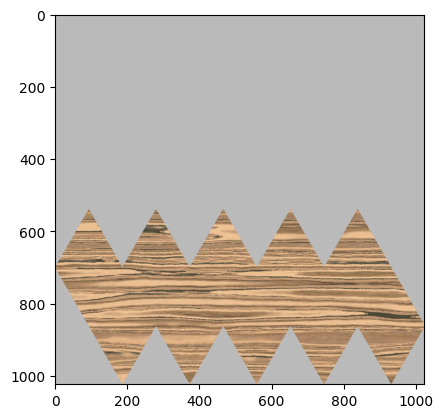

In [61]:
plt.imshow(scene['mat']['d'].detach().cpu()**0.454)

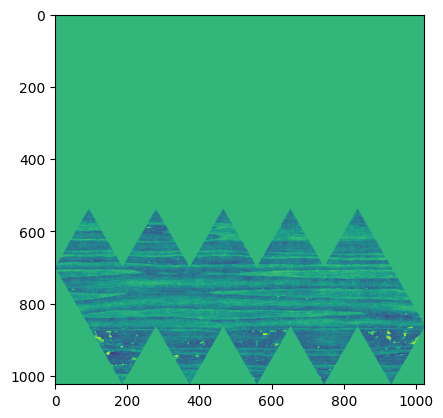

In [62]:
plt.imshow(scene['mat']['r'].detach().cpu()**0.454)

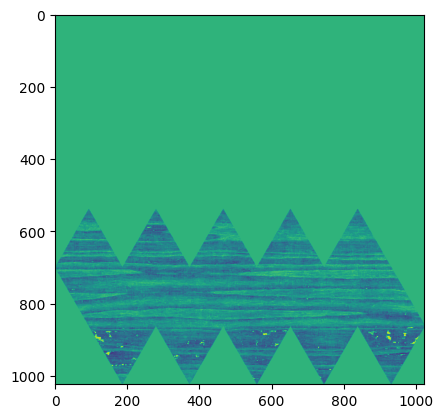

In [64]:
plt.imshow(scene['mat']['r'].detach().cpu()**0.454)

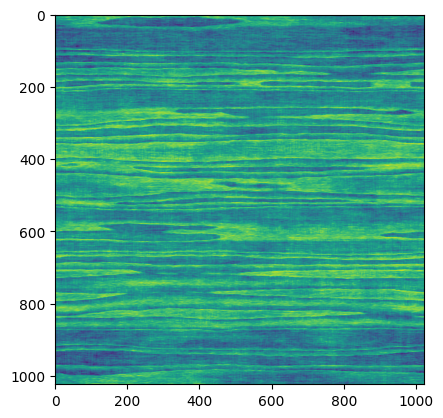

In [56]:
plt.imshow(roughness_GT.detach().cpu()**0.454)